## Carga y revision

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, roc_auc_score,
                             roc_curve, confusion_matrix)

# ── Ruta del CSV (ajusta si es necesario) ──────────────────────────────────────
CSV_PATH = "endometriosis_clean.csv"

df = pd.read_csv(CSV_PATH)

print("Shape:", df.shape)
print("\nDtypes:")
print(df.dtypes)
print("\nDistribución de Diagnosis:")
print(df["Diagnosis"].value_counts())
print("\nProporción (%):")
print(df["Diagnosis"].value_counts(normalize=True).mul(100).round(2))

Shape: (9988, 7)

Dtypes:
Age                            int64
Menstrual_Irregularity         int64
Chronic_Pain_Level             int64
Hormone_Level_Abnormality      int64
Infertility                    int64
BMI                          float64
Diagnosis                      int64
dtype: object

Distribución de Diagnosis:
Diagnosis
0    5914
1    4074
Name: count, dtype: int64

Proporción (%):
Diagnosis
0    59.21
1    40.79
Name: proportion, dtype: float64


## traing y pruebas

In [2]:
X = df.drop(columns=["Diagnosis"])
y = df["Diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} muestras  |  Test: {X_test.shape[0]} muestras")
print("\nDistribución en train:")
print(y_train.value_counts())
print("\nDistribución en test:")
print(y_test.value_counts())

Train: 7990 muestras  |  Test: 1998 muestras

Distribución en train:
Diagnosis
0    4731
1    3259
Name: count, dtype: int64

Distribución en test:
Diagnosis
0    1183
1     815
Name: count, dtype: int64


## Pipeline


In [3]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42
    ))
])

print(pipeline)

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])


## fit y evaluacion

In [4]:
# ── Entrenamiento ──────────────────────────────────────────────────────────────
pipeline.fit(X_train, y_train)

# ── Predicciones ───────────────────────────────────────────────────────────────
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

# ── Classification report ──────────────────────────────────────────────────────
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=["No endometriosis (0)", "Endometriosis (1)"]))

# ── Recall explícito de la clase positiva ─────────────────────────────────────
from sklearn.metrics import recall_score
recall_positiva = recall_score(y_test, y_pred, pos_label=1)
print(f"Recall clase positiva (Diagnosis=1): {recall_positiva:.4f}")

# ── AUC-ROC ────────────────────────────────────────────────────────────────────
auc = roc_auc_score(y_test, y_prob)
print(f"AUC-ROC: {auc:.4f}")

=== Classification Report ===
                      precision    recall  f1-score   support

No endometriosis (0)       0.64      0.68      0.66      1183
   Endometriosis (1)       0.49      0.45      0.47       815

            accuracy                           0.59      1998
           macro avg       0.57      0.57      0.57      1998
        weighted avg       0.58      0.59      0.58      1998

Recall clase positiva (Diagnosis=1): 0.4540
AUC-ROC: 0.5966


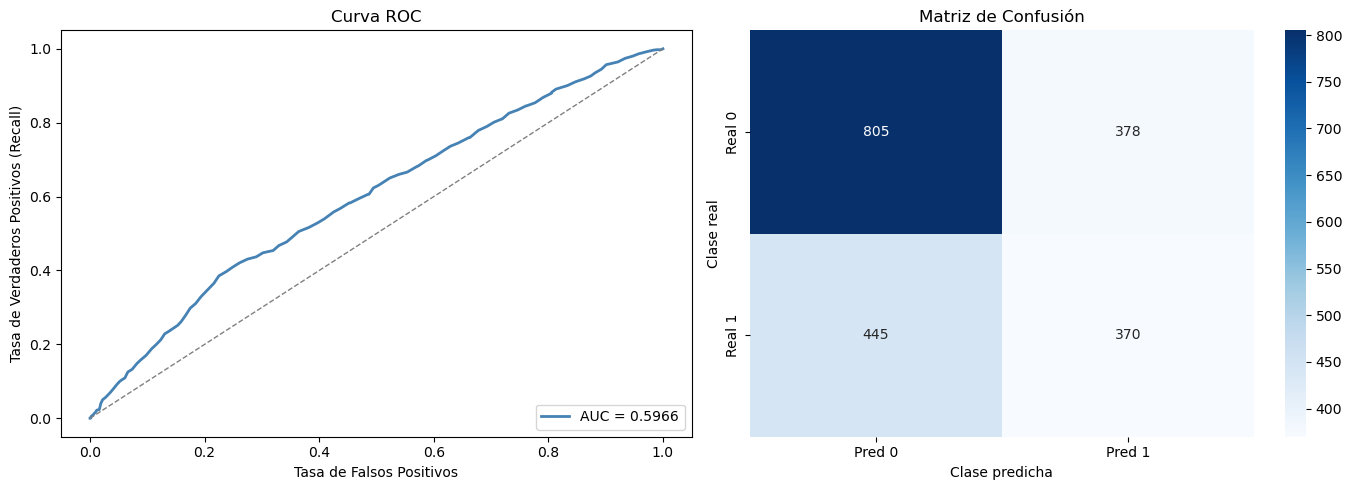

In [5]:
# ── Curva ROC ──────────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva ROC
axes[0].plot(fpr, tpr, color="steelblue", lw=2, label=f"AUC = {auc:.4f}")
axes[0].plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1)
axes[0].set_xlabel("Tasa de Falsos Positivos")
axes[0].set_ylabel("Tasa de Verdaderos Positivos (Recall)")
axes[0].set_title("Curva ROC")
axes[0].legend(loc="lower right")

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", ax=axes[1],
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["Real 0", "Real 1"]
)
axes[1].set_title("Matriz de Confusión")
axes[1].set_ylabel("Clase real")
axes[1].set_xlabel("Clase predicha")

plt.tight_layout()
plt.show()

## features

                  feature  importance
                      BMI    0.525237
                      Age    0.282171
       Chronic_Pain_Level    0.121394
Hormone_Level_Abnormality    0.038378
   Menstrual_Irregularity    0.016438
              Infertility    0.016382


C:\Users\Raquel\AppData\Local\Temp\ipykernel_8848\64804675.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


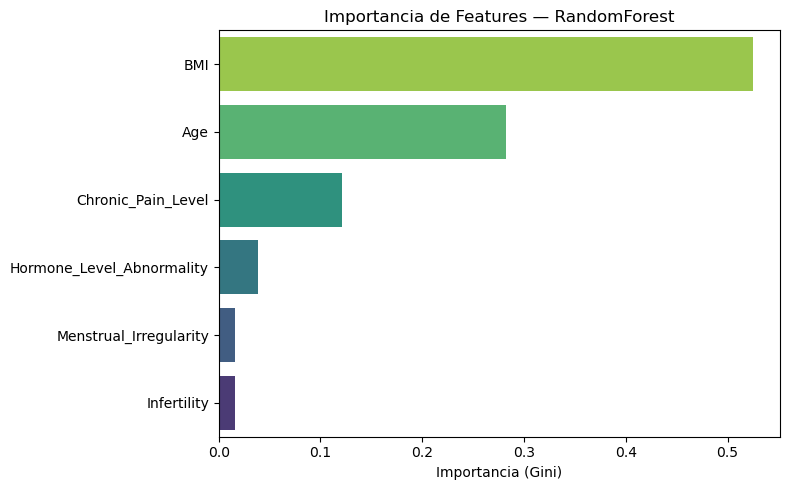

In [6]:
importances = pipeline.named_steps["clf"].feature_importances_
feature_names = X.columns.tolist()

fi_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print(fi_df.to_string(index=False))

plt.figure(figsize=(8, 5))
sns.barplot(
    data=fi_df, x="importance", y="feature",
    palette="viridis_r", orient="h"
)
plt.title("Importancia de Features — RandomForest")
plt.xlabel("Importancia (Gini)")
plt.ylabel("")
plt.tight_layout()
plt.show()